# Network Monitoring Dataset EDA aligned with `dataset.py`

This notebook documents the exact network-monitoring preprocessing and task construction used in the shared `dataset.py` file.

The important correction compared with the earlier generic EDA is that the implementation does **not** use all telemetry columns. It selects only two protocol-count features:

- `http_count_uid_in`
- `ssl_count_uid_in`

The task is therefore **two-dimensional one-step-ahead time-series forecasting**. Given the previous 24 observations of the selected HTTP and SSL telemetry features, the model predicts the next two-dimensional telemetry vector.


Observed facts from the uploaded TSV and the shared `dataset.py` pipeline:

- Raw file shape: `5,307` rows and `102` columns.
- Timestamp range: `2021-04-15 12:00:00` to `2021-05-26 15:40:00`.
- Nominal sampling interval: `10 minutes`.
- Complete 10-minute grid size over the range: `5,927` rows.
- Missing timestamps in that complete grid: `620`.
- Columns selected by `dataset.py`: `['http_count_uid_in', 'ssl_count_uid_in']`.
- Selected raw feature count used by the GRU: `2`.
- Missing values before interpolation: `http_count_uid_in=0`, `ssl_count_uid_in=2`.
- Missing values after time interpolation: `http_count_uid_in=0`, `ssl_count_uid_in=0`.
- Chronological split: `4,245` train rows and `1,062` test rows.
- Sequence length: `24` observations, equal to `4` hours of previous telemetry.
- Forecast horizon implied by `TimeseriesGenerator`: one step ahead, equal to `10` minutes ahead.
- Horizontal FL training shapes: `X_train=(4221, 24, 2)`, `y_train=(4221, 2)`.
- Horizontal FL test shapes: `X_test=(1038, 24, 2)`, `y_test=(1038, 2)`.

## 1. Imports and configuration

The constants below mirror the shared `dataset.py` file. The sampling interval is not explicitly stored as a constant in the loader, but the timestamps in the file are approximately 10-minute observations.

In [44]:
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import STL
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

DATA_PATH_CANDIDATES = [
    Path("../data/network_monitoring/buffer-20210415-20210526.tsv"),
    Path("/mnt/data/buffer-20210415-20210526.tsv"),
]

FILE_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError("Could not find buffer-20210415-20210526.tsv")

CFG_DATA_SPLIT = 0.8
CFG_SEQUENCE_LEN = 24
CFG_SAMPLING_RATE = 1
CFG_STRIDE = 1
CFG_BATCH_SIZE = 1

COLS = ["http_count_uid_in", "ssl_count_uid_in"]
TIMESTAMP_COLUMN = "ts"
NOMINAL_FREQ = "10min"

## 2. Load raw data and inspect global structure

The raw TSV contains many protocol-level telemetry columns, but the actual network-monitoring experiment selects only the two columns listed above. The full structure is still useful for understanding the source dataset.

In [45]:
raw_df = pd.read_csv(FILE_PATH, sep="\t")
raw_df[TIMESTAMP_COLUMN] = pd.to_datetime(raw_df[TIMESTAMP_COLUMN], errors="coerce")
raw_df = raw_df.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)

print("Loaded:", FILE_PATH)
print("Raw shape:", raw_df.shape)
print("Timestamp range:", raw_df[TIMESTAMP_COLUMN].min(), "to", raw_df[TIMESTAMP_COLUMN].max())

display(raw_df.head())
display(raw_df.tail())

all_feature_cols = [c for c in raw_df.columns if c != TIMESTAMP_COLUMN]
print("All telemetry columns excluding timestamp:", len(all_feature_cols))
print("Columns used by dataset.py:", COLS)

Loaded: ..\data\network_monitoring\buffer-20210415-20210526.tsv
Raw shape: (5307, 102)
Timestamp range: 2021-04-15 12:00:00 to 2021-05-26 15:40:00


,ts,conn_count_uid_in,conn_count_uid_internal,conn_count_uid_out,conn_mean_duration_in,conn_mean_duration_internal,conn_mean_duration_out,conn_nunique_uid_in,conn_nunique_uid_internal,conn_nunique_uid_out,conn_sum_orig_bytes_in,conn_sum_orig_bytes_internal,conn_sum_orig_bytes_out,conn_sum_resp_bytes_in,conn_sum_resp_bytes_internal,conn_sum_resp_bytes_out,dns_AA_F_in_count,dns_AA_F_internal_count,dns_AA_F_out_count,dns_AA_T_in_count,dns_AA_T_internal_count,dns_AA_T_out_count,dns_RA_F_in_count,dns_RA_F_internal_count,dns_RA_F_out_count,dns_RA_T_in_count,dns_RA_T_internal_count,dns_RA_T_out_count,dns_RD_F_in_count,dns_RD_F_internal_count,dns_RD_F_out_count,dns_RD_T_in_count,dns_RD_T_internal_count,dns_RD_T_out_count,dns_TC_F_in_count,dns_TC_F_internal_count,dns_TC_F_out_count,dns_TC_T_in_count,dns_TC_T_internal_count,dns_TC_T_out_count,dns_count_proto_in,dns_count_proto_internal,dns_count_proto_out,dns_count_query_in,dns_count_query_internal,dns_count_query_out,dns_count_uid_in,dns_count_uid_internal,dns_count_uid_out,dns_nunique_proto_in,dns_nunique_proto_internal,dns_nunique_proto_out,dns_nunique_query_in,dns_nunique_query_internal,dns_nunique_query_out,dns_nunique_uid_in,dns_nunique_uid_internal,dns_nunique_uid_out,dns_rejected_F_in_count,dns_rejected_F_internal_count,dns_rejected_F_out_count,dns_rejected_T_in_count,dns_rejected_T_internal_count,dns_rejected_T_out_count,http_count_uid_in,http_count_uid_internal,http_count_uid_out,http_nunique_uid_in,http_nunique_uid_internal,http_nunique_uid_out,sip_count_id.orig_h_in,sip_count_id.orig_h_out,sip_count_id.orig_p_in,sip_count_id.orig_p_out,sip_count_id.resp_h_in,sip_count_id.resp_h_out,sip_count_id.resp_p_in,sip_count_id.resp_p_out,sip_count_uid_in,sip_count_uid_out,sip_nunique_id.orig_h_in,sip_nunique_id.orig_h_out,sip_nunique_id.orig_p_in,sip_nunique_id.orig_p_out,sip_nunique_id.resp_h_in,sip_nunique_id.resp_h_out,sip_nunique_id.resp_p_in,sip_nunique_id.resp_p_out,sip_nunique_uid_in,sip_nunique_uid_out,ssh_count_uid_in,ssh_count_uid_internal,ssh_count_uid_out,ssh_nunique_uid_in,ssh_nunique_uid_internal,ssh_nunique_uid_out,ssl_count_uid_in,ssl_count_uid_internal,ssl_count_uid_out,ssl_nunique_uid_in,ssl_nunique_uid_internal,ssl_nunique_uid_out
0,2021-04-15 12:00:00,15659.0,1484.0,1725.0,5.172775,2.012251,1.331397,15659.0,1484.0,1725.0,8.063780e+06,503491.0,446589.0,43283679.0,646794.0,1.303296e+07,2554.0,746.0,967.0,231.0,1073.0,38.0,2729.0,581.0,992.0,56.0,1238.0,13.0,1748.0,2.0,393.0,1037.0,1817.0,612.0,2785.0,1819.0,1005.0,0.0,0.0,0.0,2785.0,1819.0,1005.0,2785.0,1819.0,1005.0,2785.0,1819.0,1005.0,2.0,1.0,1.0,750.0,124.0,268.0,2748.0,1267.0,998.0,2740.0,1809.0,915.0,45.0,10.0,90.0,1600.0,NaN,22.0,1308.0,NaN,3.0,108.0,NaN,108.0,NaN,108.0,NaN,108.0,NaN,108.0,NaN,1.0,NaN,1.0,NaN,108.0,NaN,1.0,NaN,108.0,NaN,5238.0,NaN,NaN,5238.0,NaN,NaN,361.0,20.0,99.0,361.0,20.0,99.0
1,2021-04-15 12:10:00,15991.0,3164.0,2671.0,56.509412,1.236075,0.918914,15991.0,3164.0,2671.0,4.671329e+08,909336.0,592053.0,67360537.0,4462129.0,3.435535e+09,3289.0,3106.0,986.0,256.0,1390.0,65.0,3497.0,1687.0,699.0,48.0,2809.0,352.0,2269.0,5.0,633.0,1276.0,4491.0,418.0,3545.0,4496.0,1051.0,0.0,0.0,0.0,3545.0,4496.0,1051.0,3545.0,4496.0,1051.0,3545.0,4496.0,1051.0,1.0,1.0,1.0,673.0,435.0,456.0,2552.0,2735.0,983.0,3141.0,4417.0,900.0,404.0,79.0,151.0,976.0,NaN,102.0,579.0,NaN,31.0,219.0,NaN,219.0,NaN,219.0,NaN,219.0,NaN,219.0,NaN,2.0,NaN,2.0,NaN,142.0,NaN,1.0,NaN,219.0,NaN,1353.0,NaN,NaN,1353.0,NaN,NaN,306.0,124.0,108.0,306.0,124.0,108.0
2,2021-04-15 12:20:00,20969.0,2068.0,1875.0,2.872722,1.922801,1.696825,20969.0,2068.0,1875.0,4.130670e+06,527784.0,503224.0,58448217.0,1127842.0,9.253731e+07,2916.0,1674.0,828.0,237.0,1092.0,49.0,3108.0,1008.0,756.0,45.0,1758.0,121.0,1786.0,12.0,637.0,1367.0,2754.0,240.0,3153.0,2766.0,877.0,0.0,0.0,0.0,3153.0,2766.0,877.0,3153.0,2766.0,877.0,3153.0,2766.0,877.0,1.0,1.0,1.0,787.0,431.0,491.0,2641.0,1825.0,872.0,2733.0,2673.0,662.0,420.0,93.0,215.0,916.0,NaN,29.0,653.0,NaN,4.0,85.0,NaN

,ts,conn_count_uid_in,conn_count_uid_internal,conn_count_uid_out,conn_mean_duration_in,conn_mean_duration_internal,conn_mean_duration_out,conn_nunique_uid_in,conn_nunique_uid_internal,conn_nunique_uid_out,conn_sum_orig_bytes_in,conn_sum_orig_bytes_internal,conn_sum_orig_bytes_out,conn_sum_resp_bytes_in,conn_sum_resp_bytes_internal,conn_sum_resp_bytes_out,dns_AA_F_in_count,dns_AA_F_internal_count,dns_AA_F_out_count,dns_AA_T_in_count,dns_AA_T_internal_count,dns_AA_T_out_count,dns_RA_F_in_count,dns_RA_F_internal_count,dns_RA_F_out_count,dns_RA_T_in_count,dns_RA_T_internal_count,dns_RA_T_out_count,dns_RD_F_in_count,dns_RD_F_internal_count,dns_RD_F_out_count,dns_RD_T_in_count,dns_RD_T_internal_count,dns_RD_T_out_count,dns_TC_F_in_count,dns_TC_F_internal_count,dns_TC_F_out_count,dns_TC_T_in_count,dns_TC_T_internal_count,dns_TC_T_out_count,dns_count_proto_in,dns_count_proto_internal,dns_count_proto_out,dns_count_query_in,dns_count_query_internal,dns_count_query_out,dns_count_uid_in,dns_count_uid_internal,dns_count_uid_out,dns_nunique_proto_in,dns_nunique_proto_internal,dns_nunique_proto_out,dns_nunique_query_in,dns_nunique_query_internal,dns_nunique_query_out,dns_nunique_uid_in,dns_nunique_uid_internal,dns_nunique_uid_out,dns_rejected_F_in_count,dns_rejected_F_internal_count,dns_rejected_F_out_count,dns_rejected_T_in_count,dns_rejected_T_internal_count,dns_rejected_T_out_count,http_count_uid_in,http_count_uid_internal,http_count_uid_out,http_nunique_uid_in,http_nunique_uid_internal,http_nunique_uid_out,sip_count_id.orig_h_in,sip_count_id.orig_h_out,sip_count_id.orig_p_in,sip_count_id.orig_p_out,sip_count_id.resp_h_in,sip_count_id.resp_h_out,sip_count_id.resp_p_in,sip_count_id.resp_p_out,sip_count_uid_in,sip_count_uid_out,sip_nunique_id.orig_h_in,sip_nunique_id.orig_h_out,sip_nunique_id.orig_p_in,sip_nunique_id.orig_p_out,sip_nunique_id.resp_h_in,sip_nunique_id.resp_h_out,sip_nunique_id.resp_p_in,sip_nunique_id.resp_p_out,sip_nunique_uid_in,sip_nunique_uid_out,ssh_count_uid_in,ssh_count_uid_internal,ssh_count_uid_out,ssh_nunique_uid_in,ssh_nunique_uid_internal,ssh_nunique_uid_out,ssl_count_uid_in,ssl_count_uid_internal,ssl_count_uid_out,ssl_nunique_uid_in,ssl_nunique_uid_internal,ssl_nunique_uid_out
5302,2021-05-26 15:00:00,10706.0,2120.0,1887.0,5.136144,0.430857,1.883986,10706.0,2120.0,1887.0,3.054412e+06,502609.0,5.075710e+05,46275520.0,1177224.0,4.766141e+08,2064.0,1953.0,609.0,140.0,1108.0,48.0,2152.0,1056.0,647.0,52.0,2005.0,10.0,1355.0,0.0,640.0,849.0,3061.0,17.0,2204.0,3061.0,657.0,0.0,0.0,0.0,2204.0,3061.0,657.0,2204.0,3061.0,657.0,2204.0,3061.0,657.0,1.0,1.0,1.0,636.0,300.0,480.0,1723.0,1908.0,653.0,2149.0,3054.0,536.0,55.0,7.0,121.0,832.0,NaN,160.0,763.0,NaN,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1433.0,NaN,NaN,1433.0,NaN,NaN,358.0,4.0,124.0,358.0,4.0,124.0
5303,2021-05-26 15:10:00,15056.0,2774.0,2304.0,3.879625,0.329900,1.993108,15056.0,2774.0,2304.0,4.811211e+10,650556.0,5.727990e+05,60865115.0,3651445.0,3.653801e+09,2305.0,2754.0,842.0,116.0,1271.0,53.0,2386.0,1447.0,650.0,35.0,2578.0,245.0,1634.0,0.0,601.0,787.0,4025.0,294.0,2421.0,4025.0,895.0,0.0,0.0,0.0,2421.0,4025.0,895.0,2421.0,4025.0,895.0,2421.0,4025.0,895.0,1.0,1.0,1.0,535.0,331.0,408.0,1868.0,2464.0,830.0,2372.0,4020.0,801.0,49.0,5.0,94.0,590.0,NaN,160.0,565.0,NaN,2.0,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,1.0,NaN,4.0,NaN,4.0,NaN,1.0,NaN,4.0,NaN,2007.0,NaN,NaN,2007.0,NaN,NaN,560.0,96.0,115.0,560.0,96.0,115.0
5304,2021-05-26 15:20:00,14280.0,2314.0,2037.0,18.183580,0.406273,3.231494,14280.0,2314.0,2037.0,3.789952e+10,498410.0,4.295492e+09,53541416.0,954116.0,1.143805e+10,2393.0,2217.0,604.0,173.0,1130.0,46.0,2513.0,1179.0,499.0,53.0,2168.0,151.0,1859.0,0.0,361.0,707.0,3347.0,289.0,2566.0,3347.0,650.0,0.0,0.0,0.0,2566.0,3347.0,650.0,2566.0,3347.0,650.0,2566.0,3347.0,650.0,2.0,1.0,1.0,557.0,335.0,276.0,2058.0,2102.0,606.0,2516.0,3345.0,552.0,50.0,2.0,98.0,671.0,NaN,160.0,572.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

All telemetry columns excluding timestamp: 101
Columns used by dataset.py: ['http_count_uid_in', 'ssl_count_uid_in']


## 3. Protocol groups in the raw source file

The selected experiment uses only HTTP and SSL inbound unique-ID counts. However, the source file also includes other protocol groups. This explains the broader dataset context while keeping the implemented task precise.

In [46]:
def protocol_prefix(col):
    return col.split("_")[0]

feature_groups = (
    pd.Series([protocol_prefix(c) for c in all_feature_cols], name="protocol_group")
    .value_counts()
    .rename_axis("protocol_group")
    .reset_index(name="num_columns")
)

display(feature_groups)

selected_group_info = pd.DataFrame({
    "selected_column": COLS,
    "protocol_group": [protocol_prefix(c) for c in COLS],
})
display(selected_group_info)

,protocol_group,num_columns
0,dns,48
1,sip,20
2,conn,15
3,http,6
4,ssh,6
5,ssl,6


,selected_column,protocol_group
0,http_count_uid_in,http
1,ssl_count_uid_in,ssl


## 4. Reproduce `dataset.py`: select two telemetry features

The loader selects only:

```python
cols = ["http_count_uid_in", "ssl_count_uid_in"]
data_df = data_df[cols]
```

This means the GRU's `multivariate` value for this dataset is 2 in the horizontal time-series setting.

In [47]:
data_df = raw_df.set_index(TIMESTAMP_COLUMN)
data_df.index = pd.to_datetime(data_df.index)

data_df = data_df[COLS]

print("Selected dataframe shape:", data_df.shape)
display(data_df.head())
display(data_df.tail())

display(data_df.describe().T)

Selected dataframe shape: (5307, 2)


,http_count_uid_in,ssl_count_uid_in
ts,,
2021-04-15 12:00:00,1600.0,361.0
2021-04-15 12:10:00,976.0,306.0
2021-04-15 12:20:00,916.0,291.0
2021-04-15 12:30:00,1052.0,354.0
2021-04-15 12:40:00,995.0,434.0


,http_count_uid_in,ssl_count_uid_in
ts,,
2021-05-26 15:00:00,832.0,358.0
2021-05-26 15:10:00,590.0,560.0
2021-05-26 15:20:00,671.0,313.0
2021-05-26 15:30:00,724.0,316.0
2021-05-26 15:40:00,636.0,440.0


,count,mean,std,min,25%,50%,75%,max
http_count_uid_in,5307.0,1228.070661,1396.044954,1.0,578.0,754.0,1232.5,14837.0
ssl_count_uid_in,5305.0,341.358153,102.566549,1.0,282.0,328.0,385.0,1440.0


## 5. Timestamp continuity

The dataset is used as a time series, so temporal ordering and gaps matter. The shared loader does not explicitly reindex to a complete grid; it uses the timestamps available in the file and interpolates missing feature values over time.

,interval,count
0,0 days 00:10:00,5302
1,0 days 00:20:00,1
2,2 days 15:50:00,1
3,1 days 15:20:00,1
4,0 days 00:30:00,1


Complete 10-minute grid rows: 5927
Actual rows: 5307
Missing timestamps on complete grid: 620
Duplicate timestamps: 0


,missing_timestamp
0,2021-05-04 21:30:00
1,2021-05-04 21:50:00
2,2021-05-04 22:00:00
3,2021-05-04 22:10:00
4,2021-05-04 22:20:00
5,2021-05-04 22:30:00
6,2021-05-04 22:40:00
7,2021-05-04 22:50:00
8,2021-05-04 23:00:00
9,2021-05-04 23:10:00


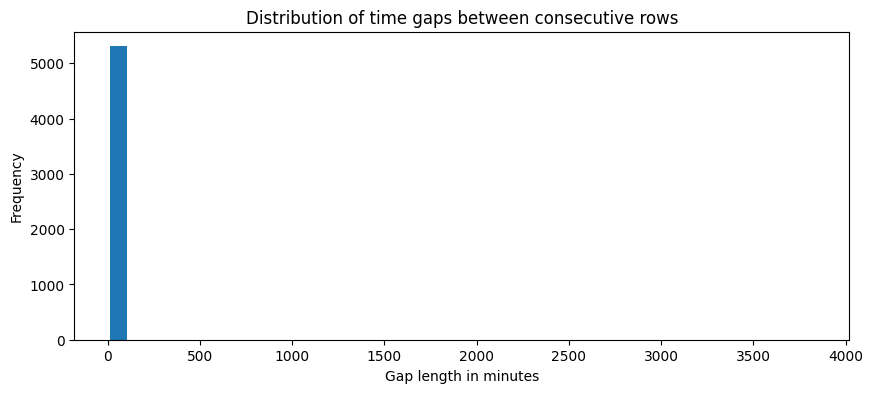

In [48]:
intervals = data_df.index.to_series().diff().dropna()
interval_summary = intervals.value_counts().rename_axis("interval").reset_index(name="count")
display(interval_summary.head(20))

full_index = pd.date_range(data_df.index.min(), data_df.index.max(), freq=NOMINAL_FREQ)
missing_timestamps = full_index.difference(data_df.index)

print("Complete 10-minute grid rows:", len(full_index))
print("Actual rows:", len(data_df))
print("Missing timestamps on complete grid:", len(missing_timestamps))
print("Duplicate timestamps:", int(data_df.index.duplicated().sum()))

if len(missing_timestamps) > 0:
    display(pd.DataFrame({"missing_timestamp": missing_timestamps[:100]}))

plt.figure(figsize=(10, 4))
intervals.dt.total_seconds().div(60).plot(kind="hist", bins=40)
plt.title("Distribution of time gaps between consecutive rows")
plt.xlabel("Gap length in minutes")
plt.ylabel("Frequency")
plt.show()

## 6. Missing-value handling by time interpolation

The loader applies:

```python
data_df = data_df.interpolate(method="time")
```

This fills missing values in the selected HTTP and SSL series using time-aware interpolation.

In [49]:
missing_before = data_df.isna().sum().to_frame("missing_before_interpolation")
display(missing_before)

data_interp = data_df.interpolate(method="time")

missing_after = data_interp.isna().sum().to_frame("missing_after_interpolation")
display(missing_after)

display(data_interp.describe().T)

,missing_before_interpolation
http_count_uid_in,0
ssl_count_uid_in,2


,missing_after_interpolation
http_count_uid_in,0
ssl_count_uid_in,0


,count,mean,std,min,25%,50%,75%,max
http_count_uid_in,5307.0,1228.070661,1396.044954,1.0,578.0,754.0,1232.5,14837.0
ssl_count_uid_in,5307.0,341.276148,102.658755,1.0,282.0,328.0,384.5,1440.0


## 7. Visualize selected raw and interpolated series

These plots make the actual two-feature forecasting target understandable in the thesis.

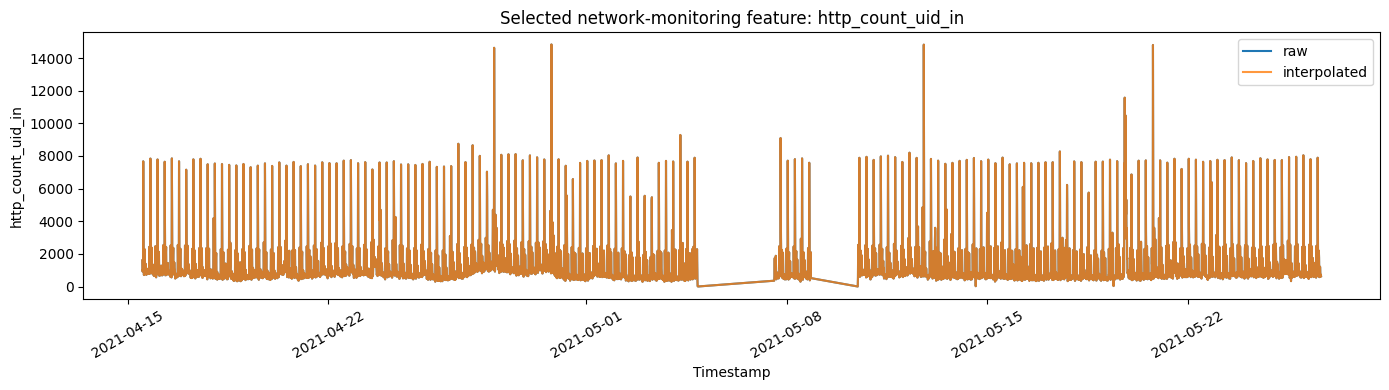

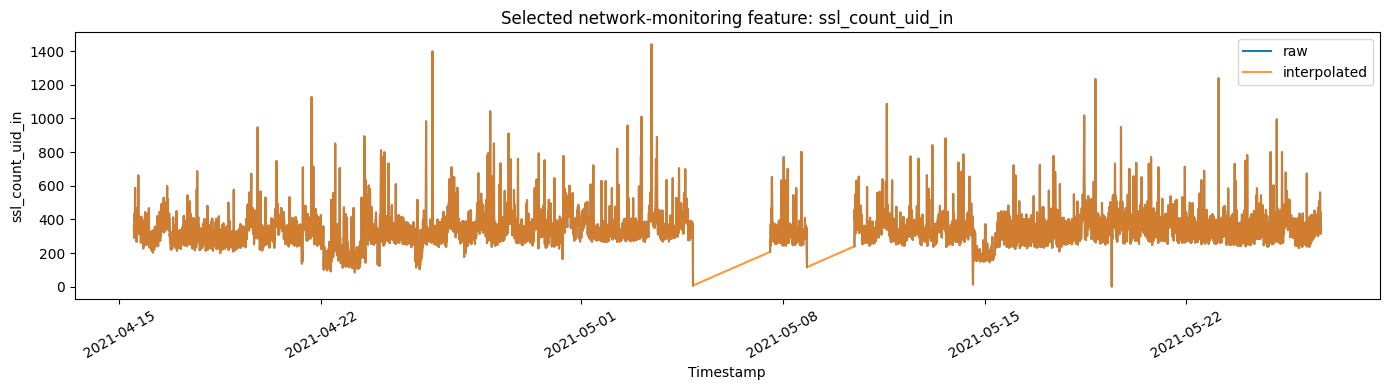

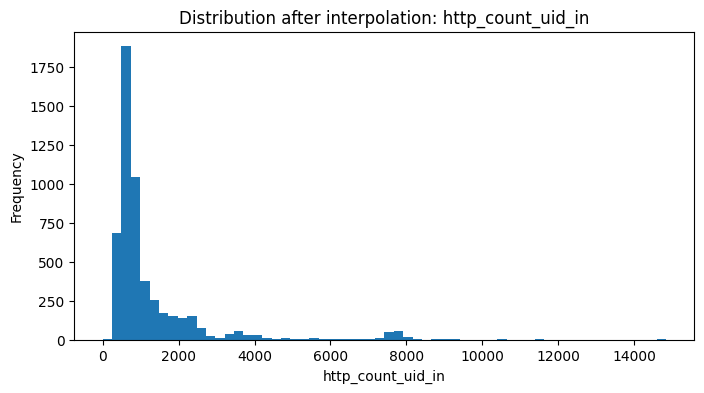

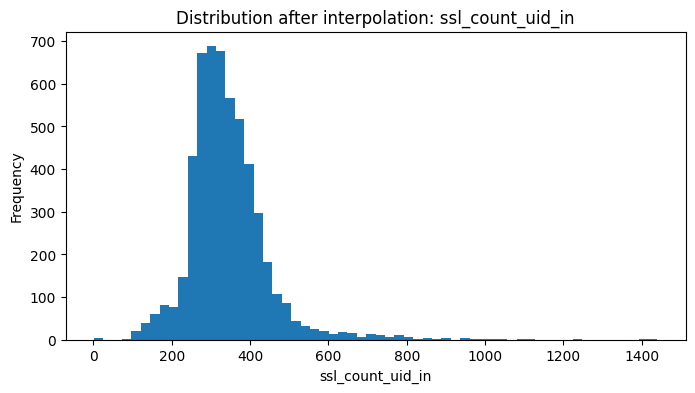

In [50]:
for col in COLS:
    plt.figure(figsize=(14, 4))
    plt.plot(data_df.index, data_df[col], label="raw")
    plt.plot(data_interp.index, data_interp[col], label="interpolated", alpha=0.8)
    plt.title(f"Selected network-monitoring feature: {col}")
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

for col in COLS:
    plt.figure(figsize=(8, 4))
    data_interp[col].plot(kind="hist", bins=60)
    plt.title(f"Distribution after interpolation: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 8. Train/test split

The loader uses a chronological 80/20 split before normalization. This is appropriate for forecasting because it avoids training on future observations.

In [51]:
rows = len(data_interp)
train_size = int(rows * CFG_DATA_SPLIT)

data_train_df_raw = data_interp[:train_size]
data_test_df_raw = data_interp[train_size:]

print("Total rows:", rows)
print("Train rows:", len(data_train_df_raw))
print("Test rows:", len(data_test_df_raw))
print("Train period:", data_train_df_raw.index.min(), "to", data_train_df_raw.index.max())
print("Test period:", data_test_df_raw.index.min(), "to", data_test_df_raw.index.max())

display(data_train_df_raw.describe().T)
display(data_test_df_raw.describe().T)

Total rows: 5307
Train rows: 4245
Test rows: 1062
Train period: 2021-04-15 12:00:00 to 2021-05-19 06:40:00
Test period: 2021-05-19 06:50:00 to 2021-05-26 15:40:00


,count,mean,std,min,25%,50%,75%,max
http_count_uid_in,4245.0,1217.352415,1371.859881,1.0,568.0,760.0,1234.0,14837.0
ssl_count_uid_in,4245.0,336.753243,104.084554,7.0,280.0,326.0,378.0,1440.0


,count,mean,std,min,25%,50%,75%,max
http_count_uid_in,1062.0,1270.913371,1488.707314,28.0,605.0,735.5,1211.0,14804.0
ssl_count_uid_in,1062.0,359.354991,94.660747,1.0,292.0,345.5,405.0,1239.0


## 9. Transform and normalize

The loader first replaces negative values with `epsilon=1` through `transform`. The optional IQR peak removal is implemented but not used because `remove_peak=False` by default.

Then min-max scaling is fitted on the training data only and reused on the test data.

In [52]:
def transform(data, epsilon=1, remove_peak=False):
    if remove_peak:
        q_min, q_max = np.percentile(data, [25, 75], axis=0)
        iqr = q_max - q_min
        iqr_min = q_min - 1.5 * iqr
        iqr_max = q_max + 1.5 * iqr
        data = np.clip(data, a_min=iqr_min, a_max=iqr_max)
    data = np.where(data < 0, epsilon, data)
    return data

def normalize(data, scaler=None):
    if len(data.shape) == 1 and isinstance(data, np.ndarray):
        data = data.reshape(-1, 1)
    if not scaler:
        scaler = MinMaxScaler(feature_range=(0, 1))
        norm_data = scaler.fit_transform(data)
        norm_data = np.where(norm_data <= 0, 1e-3, norm_data)
    else:
        norm_data = scaler.transform(data)
    return norm_data, scaler

data_train = data_train_df_raw.values.astype("float32")
data_test = data_test_df_raw.values.astype("float32")

data_train_n = transform(data_train)
data_train_scaled, scaler = normalize(data_train_n)

trans_test = transform(data_test)
data_test_scaled, _ = normalize(trans_test, scaler)

data_train_df = pd.DataFrame(data_train_scaled, columns=data_interp.columns, index=data_interp.index[:train_size])
data_test_df = pd.DataFrame(data_test_scaled, columns=data_interp.columns, index=data_interp.index[train_size:])

print("Train scaled min/max:")
display(pd.DataFrame({"min": data_train_df.min(), "max": data_train_df.max()}))

print("Test scaled min/max:")
display(pd.DataFrame({"min": data_test_df.min(), "max": data_test_df.max()}))

print("Scaler data_min_:", scaler.data_min_)
print("Scaler data_max_:", scaler.data_max_)

Train scaled min/max:


,min,max
http_count_uid_in,0.001000,1.0
ssl_count_uid_in,0.000725,1.0


Test scaled min/max:


,min,max
http_count_uid_in,0.001820,0.997776
ssl_count_uid_in,-0.004187,0.859735


Scaler data_min_: [1. 7.]
Scaler data_max_: [14837.  1440.]


## 10. STL decomposition

The loader decomposes each normalized feature using STL with `period=CFG_SEQUENCE_LEN`, i.e. 24 observations. Since the sampling interval is 10 minutes, this period corresponds to 4 hours.

The decomposition produces trend, seasonal, and residual components for each selected telemetry series.

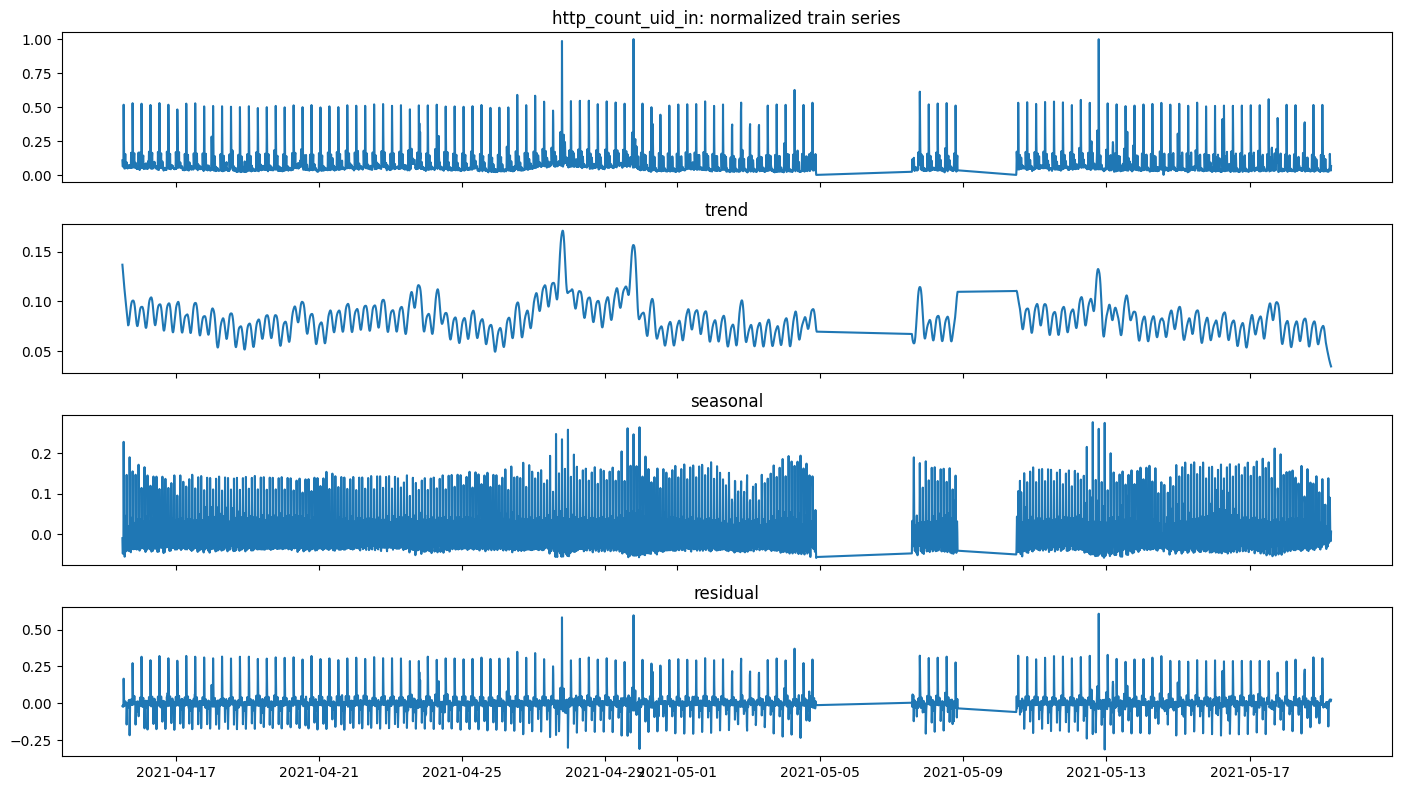

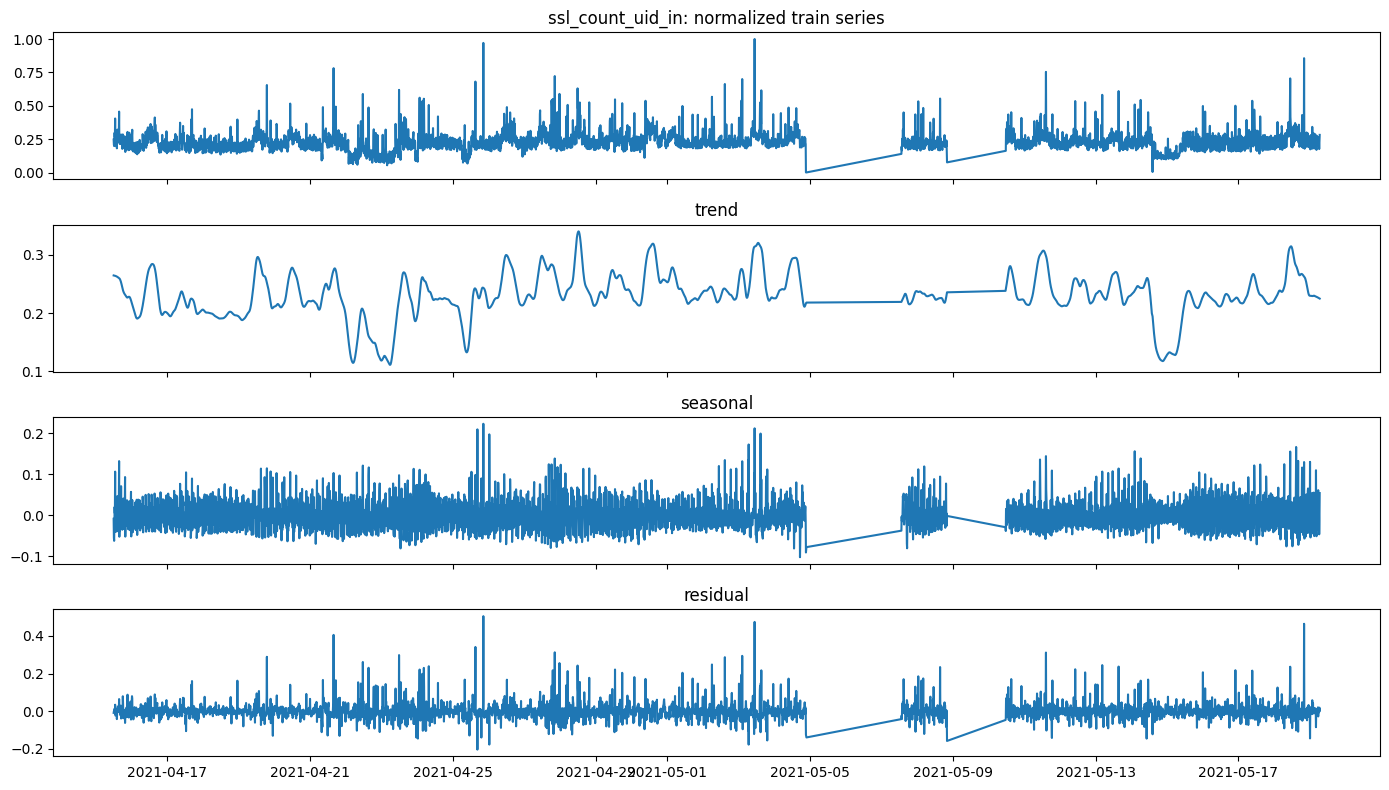

In [53]:
def get_stl_decomposed(data: pd.DataFrame, period: int, resample="10min"):
    stled = lambda x: {"trend": x.trend, "seasonal": x.seasonal, "resid": x.resid}
    features_decompose = {}

    for i, col_name in enumerate(data.columns):
        try:
            res = STL(data[col_name], period=period).fit()
        except ValueError as e:
            print(f"Unable to STL {col_name} feature, e: {e}")
        else:
            features_decompose[col_name] = stled(res)
    return features_decompose

ftrs_decomposed_train = get_stl_decomposed(data_train_df, period=CFG_SEQUENCE_LEN)
ftrs_decomposed_test = get_stl_decomposed(data_test_df, period=CFG_SEQUENCE_LEN)

for col in COLS:
    comp = ftrs_decomposed_train[col]
    fig, ax = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
    ax[0].plot(data_train_df.index, data_train_df[col])
    ax[0].set_title(f"{col}: normalized train series")
    ax[1].plot(comp["trend"].index, comp["trend"])
    ax[1].set_title("trend")
    ax[2].plot(comp["seasonal"].index, comp["seasonal"])
    ax[2].set_title("seasonal")
    ax[3].plot(comp["resid"].index, comp["resid"])
    ax[3].set_title("residual")
    plt.tight_layout()
    plt.show()

## 11. Horizontal FL representation

For the horizontal/IID setting, the loader reconstructs the selected features differently:

- `http_count_uid_in`: trend + seasonal + residual, which reconstructs the normalized series.
- `ssl_count_uid_in`: trend + seasonal, which removes the residual component.

The resulting dataframe still has two columns and is converted into multivariate time-series windows.

In [54]:
def get_stl_one(ftrs_dec, col_name, partition_type: Literal["iid", "vert"] = "iid"):
    if col_name == "http_count_uid_in" and partition_type == "iid":
        df = (
            ftrs_dec[col_name]["trend"]
            + ftrs_dec[col_name]["seasonal"]
            + ftrs_dec[col_name]["resid"]
        )
    elif col_name == "ssl_count_uid_in" or partition_type == "vert":
        df = ftrs_dec[col_name]["trend"] + ftrs_dec[col_name]["seasonal"]
    return df

def get_stl(ftrs_dec, protocols, partition_type: Literal["iid", "vert"] = "iid"):
    df = pd.DataFrame()
    for col_name in protocols:
        dc = get_stl_one(ftrs_dec, col_name, partition_type)
        df = pd.concat([df, dc], axis=1)
    df.columns = protocols
    return df

df_train = get_stl(ftrs_decomposed_train, COLS, "iid")
np_train = df_train.to_numpy()

df_test = get_stl(ftrs_decomposed_test, COLS, "iid")
np_test = df_test.to_numpy()

print("Horizontal train dataframe shape:", df_train.shape)
print("Horizontal test dataframe shape:", df_test.shape)

display(df_train.head())
display(df_train.describe().T)

Horizontal train dataframe shape: (4245, 2)
Horizontal test dataframe shape: (1062, 2)


,http_count_uid_in,ssl_count_uid_in
2021-04-15 12:00:00,0.107778,0.255746
2021-04-15 12:10:00,0.065719,0.208872
2021-04-15 12:20:00,0.061674,0.201731
2021-04-15 12:30:00,0.070841,0.238670
2021-04-15 12:40:00,0.066999,0.284125


,count,mean,std,min,25%,50%,75%,max
http_count_uid_in,4245.0,0.081987,0.092468,0.001000,0.038218,0.051159,0.083109,1.000000
ssl_count_uid_in,4245.0,0.230113,0.052561,0.066484,0.197296,0.228260,0.261594,0.526012


## 12. Time-series window generation

The loader uses `tensorflow.keras.preprocessing.sequence.TimeseriesGenerator` with:

- `length=24`,
- `sampling_rate=1`,
- `stride=1`,
- `batch_size=1`.

For a multivariate input with two columns, each sample contains 24 previous observations and the target is the next two-feature vector.

In [55]:
def tsg_to_dataset(tsg: TimeseriesGenerator) -> np.array:
    tsg_len = len(tsg)
    one_entry = tsg[0]
    x_shape = one_entry[0][0].shape
    y_shape = one_entry[1][0].shape
    x, y = [], []
    for sequence, predicted_val in tsg:
        x.append(sequence)
        y.append(predicted_val)
    x = np.array(x).reshape((tsg_len, *x_shape))
    y = np.array(y).reshape((tsg_len, *y_shape))
    return x, y

tsg_params = {
    "length": CFG_SEQUENCE_LEN,
    "sampling_rate": CFG_SAMPLING_RATE,
    "stride": CFG_STRIDE,
    "batch_size": CFG_BATCH_SIZE,
}

tsg_train = TimeseriesGenerator(np_train, np_train, **tsg_params)
tsg_test = TimeseriesGenerator(np_test, np_test, **tsg_params)

data_train_x, data_train_y = tsg_to_dataset(tsg_train)
data_test_x, data_test_y = tsg_to_dataset(tsg_test)

network_data_train = (data_train_x, data_train_y)
network_data_test = (data_test_x, data_test_y)

print("Horizontal network_data_train X shape:", data_train_x.shape)
print("Horizontal network_data_train y shape:", data_train_y.shape)
print("Horizontal network_data_test X shape:", data_test_x.shape)
print("Horizontal network_data_test y shape:", data_test_y.shape)

print("GRU input shape:", data_train_x.shape[1:])
print("GRU output units required:", data_train_y.shape[1])

Horizontal network_data_train X shape: (4221, 24, 2)
Horizontal network_data_train y shape: (4221, 2)
Horizontal network_data_test X shape: (1038, 24, 2)
Horizontal network_data_test y shape: (1038, 2)
GRU input shape: (24, 2)
GRU output units required: 2


## 13. Vertical FL feature-specific representation

The loader also prepares a vertical-FL-style representation. In this case, each feature is treated separately:

- one dataset for `http_count_uid_in`,
- one dataset for `ssl_count_uid_in`.

For vertical decomposition, both selected features use `trend + seasonal`, so residual components are removed.

In [57]:
df_train_v = get_stl(ftrs_decomposed_train, COLS, "vert")
np_train_v = df_train_v.to_numpy()

df_test_v = get_stl(ftrs_decomposed_test, COLS, "vert")
np_test_v = df_test_v.to_numpy()

dec_train_http, dec_np_train_http = (
    df_train_v["http_count_uid_in"],
    df_train_v["http_count_uid_in"].to_numpy(),
)
dec_test_http, dec_np_test_http = (
    df_test_v["http_count_uid_in"],
    df_test_v["http_count_uid_in"].to_numpy(),
)
dec_train_ssl, dec_np_train_ssl = (
    df_train_v["ssl_count_uid_in"],
    df_train_v["ssl_count_uid_in"].to_numpy(),
)
dec_test_ssl, dec_np_test_ssl = (
    df_test_v["ssl_count_uid_in"],
    df_test_v["ssl_count_uid_in"].to_numpy(),
)

tsg_http_train = TimeseriesGenerator(dec_np_train_http, dec_np_train_http, **tsg_params)
tsg_http_test = TimeseriesGenerator(dec_np_test_http, dec_np_test_http, **tsg_params)

tsg_ssl_train = TimeseriesGenerator(dec_np_train_ssl, dec_np_train_ssl, **tsg_params)
tsg_ssl_test = TimeseriesGenerator(dec_np_test_ssl, dec_np_test_ssl, **tsg_params)

data_train_http_x, data_train_http_y = tsg_to_dataset(tsg_http_train)
data_test_http_x, data_test_http_y = tsg_to_dataset(tsg_http_test)

data_train_ssl_x, data_train_ssl_y = tsg_to_dataset(tsg_ssl_train)
data_test_ssl_x, data_test_ssl_y = tsg_to_dataset(tsg_ssl_test)

network_feature_data_train = [
    (data_train_http_x, data_train_http_y),
    (data_train_ssl_x, data_train_ssl_y),
]

network_feature_data_test = [
    (data_test_http_x, data_test_http_y),
    (data_test_ssl_x, data_test_ssl_y),
]

print("HTTP train X/y:", data_train_http_x.shape, data_train_http_y.shape)
print("HTTP test X/y:", data_test_http_x.shape, data_test_http_y.shape)
print("SSL train X/y:", data_train_ssl_x.shape, data_train_ssl_y.shape)
print("SSL test X/y:", data_test_ssl_x.shape, data_test_ssl_y.shape)

HTTP train X/y: (4221, 24) (4221,)
HTTP test X/y: (1038, 24) (1038,)
SSL train X/y: (4221, 24) (4221,)
SSL test X/y: (1038, 24) (1038,)


## 14. Check against the GRU model

The shared `model.py` uses:

```python
inputs = layers.Input(shape=(sequence_len, multivariate))
...
outputs = layers.Dense(units=multivariate * sequence_len_y, activation="sigmoid")(h)
model.compile(loss="mean_squared_error", optimizer=opt, metrics=["mse", "mae"])
```

For the horizontal network-monitoring dataset:

- `sequence_len = 24`,
- `multivariate = 2`,
- `sequence_len_y = 1`,
- output units = `2`.

In [58]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, Model

    multivariate = data_train_x.shape[-1]
    sequence_len_y = 1

    inputs = layers.Input(shape=(CFG_SEQUENCE_LEN, multivariate))
    h = layers.GRU(units=16, return_sequences=True)(inputs)
    h = layers.Dropout(0.1)(h)
    h = layers.GRU(units=80, return_sequences=True)(h)
    h = layers.Dropout(0.05)(h)
    h = layers.GRU(units=40, return_sequences=True)(h)
    h = layers.Dropout(0.25)(h)
    h = layers.GRU(units=96, return_sequences=False)(h)
    h = layers.Dropout(0.2)(h)
    outputs = layers.Dense(units=multivariate * sequence_len_y, activation="sigmoid")(h)

    model = Model(inputs=inputs, outputs=outputs, name="network_monitoring_gru")
    model.compile(loss="mean_squared_error", optimizer=keras.optimizers.Adam(0.001), metrics=["mse", "mae"])
    model.summary()
except Exception as e:
    print("TensorFlow model summary skipped:", repr(e))

Model: "network_monitoring_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24, 2)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 24, 16)              │             960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 24, 80)              │          23,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 80)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 24, 40)              │          14,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24, 40)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ (None, 96)                  │          39,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │             194 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,058 (308.82 KB)

 Trainable params: 79,058 (308.82 KB)

 Non-trainable params: 0 (0.00 B)